TESTING WITH XGBOOST

###### Since XGBOOST can handle NULL values and OUTLIERS. I am going to get rid of leaky features only

In [71]:
import pandas as pd

pathA = r'data\processed\aggregated_setA.csv'
pathB = r'data\processed\aggregated_setB.csv'

dfA = pd.read_csv(pathA)
dfB = pd.read_csv(pathB)

In [72]:
pd.set_option('display.max_rows', None)
dfA.isna().sum()

HR_mean                  1
HR_std                   6
HR_max                   1
HR_min                   1
HR_count                 0
O2Sat_mean              12
O2Sat_std               22
O2Sat_max               12
O2Sat_min               12
O2Sat_count              0
Temp_mean              235
Temp_std               475
Temp_max               235
Temp_min               235
Temp_count               0
SBP_mean               258
SBP_std                318
SBP_max                258
SBP_min                258
SBP_count                0
MAP_mean                 2
MAP_std                 10
MAP_max                  2
MAP_min                  2
MAP_count                0
DBP_mean              7384
DBP_std               7563
DBP_max               7384
DBP_min               7384
DBP_count                0
Resp_mean               28
Resp_std                51
Resp_max                28
Resp_min                28
Resp_count               0
BaseExcess_mean       7684
BaseExcess_std        9412
B

In [73]:
leaky_features_to_drop = [
    'ICULOS_max',
    'HR_count',
    'O2Sat_count',
    'Temp_count',
    'SBP_count',
    'MAP_count',
    'DBP_count',
    'Resp_count',
    'FiO2_count',
    'Lactate_count',
    'Calcium_count',
    'pH_count',
    'BaseExcess_count',
    'PaCO2_count',
    'Phosphate_count',
    'Glucose_count',
    'Hct_count',
    'Hgb_count',
    'PTT_count',
    'Platelets_count',
    'Creatinine_count',
    'Potassium_count',
    'Magnesium_count',
    'Chloride_count',
    'BUN_count',
    'WBC_count',
    'HCO3_count',
    'Bilirubin_total_count',
    'TroponinI_count'
]

not_important = ['Unit2_first','Unit1_first']
to_remove = leaky_features_to_drop + not_important

features = [f for f in dfA.columns if f not in to_remove]


In [74]:
dfA_final = dfA[features]
dfB_final = dfB[features]

In [75]:
feature_list = [f for f in dfA_final.columns if f not in ['SepsisLabel_max']]
target = ['SepsisLabel_max']

In [76]:
X = dfA_final[feature_list]
y = dfA_final[target]
X_test = dfB_final[feature_list]
y_test = dfB_final[target]

In [77]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators = 400,
    learning_rate= 0.05,
    max_depth= 4,
    min_child_weight= 5,
    gamma= 0.5,
    subsample= 0.8,
    colsample_bytree= 0.8,
    reg_alpha= 0.0,
    reg_lambda= 1.0,
    objective= "binary:logistic",
    eval_metric= "aucpr",
    tree_method= "hist",
    random_state= 42
    )

In [78]:
xgb_model.fit(X,y)

XGBClassifier(base_score=0.5, booster='gbtree', callbacks=None,
              colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric='aucpr', gamma=0.5, gpu_id=-1,
              grow_policy='depthwise', importance_type=None,
              interaction_constraints='', learning_rate=0.05, max_bin=256,
              max_cat_to_onehot=4, max_delta_step=0, max_depth=4, max_leaves=0,
              min_child_weight=5, missing=nan, monotone_constraints='()',
              n_estimators=400, n_jobs=0, num_parallel_tree=1, predictor='auto',
              random_state=42, reg_alpha=0.0, reg_lambda=1.0, ...)

In [79]:
y_predicted = xgb_model.predict(X_test)

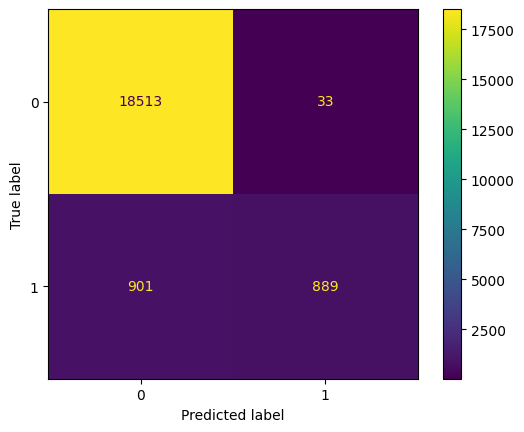

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(y_test,y_predicted)
ConfusionMatrixDisplay(confusion_matrix = cm).plot()

In [81]:
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.95      1.00      0.98     18546
           1       0.96      0.50      0.66      1790

    accuracy                           0.95     20336
   macro avg       0.96      0.75      0.82     20336
weighted avg       0.95      0.95      0.95     20336



In [82]:
import matplotlib.pyplot as plt

In [83]:
importances = xgb_model.feature_importances_

In [84]:
feat_imp = pd.DataFrame({
    "Features": X.columns,
    "Importance" : importances
}).sort_values("Importance", ascending = False)

In [85]:
feat_imp

,Features,Importance
37,Lactate_std,0.038292
36,Lactate_mean,0.021517
39,Lactate_min,0.020891
30,BaseExcess_max,0.020270
98,FiO2_std,0.018406
10,Temp_max,0.017935
53,Calcium_std,0.017187
46,BUN_max,0.016488
38,Lactate_max,0.015466
99,FiO2_max,0.015176


###### Clearly the 'Fibrinogen_count' which is a leaky feature is completely ignored by XGB model.